
## STOCHASTIC MODELING
MODULE 7 | LESSON 2


---

# **Advanced Networks**

|  |  |
|:---|:---|
|**Reading Time** |  50 minutes |
|**Prior Knowledge** | Graph theory, Networks |
|**Keywords** | Random Network, Degree distribution


---

Now that we know the basics of graph theory, its time to introduce some more advanced network types, which resemble the kind of interrelations that we can observe in practice. 

## **1. Weighted and Bipartite Networks**

In many real systems, not all connections are equally strong. We already know about how weighted graphs can represent the strength of the connections. These, connections, however, may also be of distinct forms. **Weighted networks** capture the *intensity*, *frequency*, or *strength* of interactions,   while **bipartite networks** describe systems with *two distinct types* of entities connected across groups.

\
Let's start by revisiting weighted networks more formally:


### 1.1. Weighted Networks

A **weighted network** is defined as:

$$
G = (V, E, W)
$$

where each edge $e_{ij} = (i, j) \in E$ is assigned a **weight** $w_{ij} \in \mathbb{R}$.

The **adjacency matrix** $A = [a_{ij}]$ generalizes to:

$$
a_{ij} =
\begin{cases}
w_{ij}, & \text{if \ an \ edge \ between } i \text{\ and }\ j \\
0, & \text{otherwise.}
\end{cases}
$$

As we know, weights can represent:

- **Financial exposure** → loan amount or transaction volume  
- **Similarity** → correlation between assets  
- **Distance or cost** → inverse of similarity or risk  
- **Probability** → likelihood of interaction

Weighted networks preserve more **quantitative** information about the relationships between nodes, but sometimes the strength itself is difficult to evaluate. For that reason, we may want to perform **edge weight normalization**. This simply entails **normalized** edges to make them comparable:

$$
\tilde{w}_{ij} = \frac{w_{ij}}{\max_{(i,j)\in E} w_{ij}}
$$

so that $0 \leq \tilde{w}_{ij} \leq 1$.

This allows comparing different systems (e.g., loan exposures across currencies) on a common scale.



### 1.2. Bipartite Networks

A **bipartite network** (or **two-mode network**) consists of two disjoint sets of nodes:

$$
V = V_1 \cup V_2, \quad V_1 \cap V_2 = \emptyset
$$

and edges exist **only between** these two sets — never within the same set:

$$
E \subseteq V_1 \times V_2
$$

Typical examples:

- **Financial:** firms and banks (who lends to whom)  
- **Economic:** countries and exported products  
- **Information:** investors and assets held  



**Biadjacency Matrix**

The structure of a bipartite network is represented by a **biadjacency matrix** $B$:

$$
B_{ij} =
\begin{cases}
1, & \text{if \ node }\ i \in V_1 \text{ is \ connected \ to \ node }\ j \in V_2 \\
0, & \text{otherwise.}
\end{cases}
$$

The **full adjacency** matrix of the network has a block structure:

$$
A =
\begin{bmatrix}
0 & B \\
B^\top & 0
\end{bmatrix}
$$

where zeros indicate that there are no edges within each node set.



### 1.3. Projected Networks

Sometimes we would like to analyze relationships **within** one layer (e.g., how similar firms are based on shared banks).  This is achieved through **bipartite projection**:

$$
A_{V_1} = B B^\top, \quad A_{V_2} = B^\top B
$$

Each projected network connects nodes of the same type based on the **number or strength of shared neighbors**.


### 1.4. Cosine Similarity in Weighted Projections

When edges in the bipartite network are **weighted**, the projected similarity between two nodes $i$ and $j$ can be computed using **cosine similarity**:

$$
s_{ij} = \frac{\sum_k w_{ik} w_{jk}}{\sqrt{\sum_k w_{ik}^2} \sqrt{\sum_k w_{jk}^2}}
$$

where $w_{ik}$ and $w_{jk}$ are edge weights from nodes $i$ and $j$ to common neighbors $k$.

Cosine similarity measures how **aligned** two nodes’ connection profiles are, independently of scale.


\
Overall, we may wonder which type of network to use for different context. For instance:

- **Weighted networks** capture intensity of transactions or correlations.  
- **Bipartite networks** model relationships between *two distinct entities* (e.g., investors–assets, banks–firms).  
- Within these, we can use **projections** and **similarity measures** to reveal *systemic exposure*, *common risk factors*, and *network communities*.

### 1.5. A simple example of a bipartite network

Let's build a simple example of such a network. A classic example would be a network that models firms relationships with banks. This is an important application to evaluate, for example, the propagation of systemic risk in the economy (e.g. Great Financial Crisis of 2008):

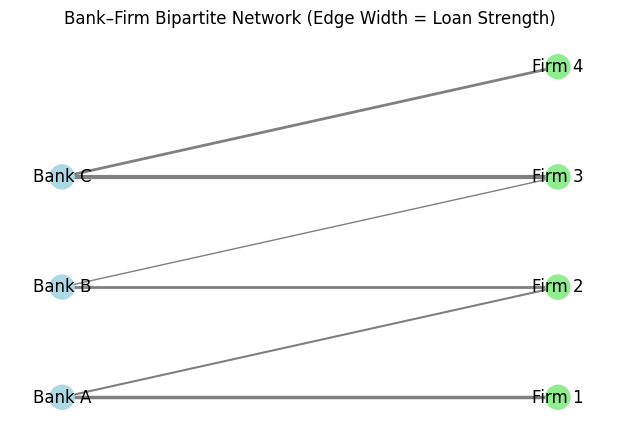

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# --- 1. Define node sets ---
banks = ["Bank A", "Bank B", "Bank C"]
firms = ["Firm 1", "Firm 2", "Firm 3", "Firm 4"]

# --- 2. Define weighted edges: (bank, firm, loan_exposure) ---
edges = [
    ("Bank A", "Firm 1", 5.0),
    ("Bank A", "Firm 2", 3.0),
    ("Bank B", "Firm 2", 4.0),
    ("Bank B", "Firm 3", 2.0),
    ("Bank C", "Firm 3", 6.0),
    ("Bank C", "Firm 4", 4.0),
]

# --- 3. Create bipartite graph ---
B = nx.Graph()
B.add_nodes_from(banks, bipartite=0)
B.add_nodes_from(firms, bipartite=1)
B.add_weighted_edges_from(edges)

# --- 4. Visualize the bipartite network ---
plt.figure(figsize=(6,4))
pos = {node: (0, i) for i, node in enumerate(banks)}
pos.update({node: (1, i) for i, node in enumerate(firms)})
weights = [B[u][v]["weight"] for u, v in B.edges()]
nx.draw(
    B,
    pos,
    with_labels=True,
    node_color=["lightblue" if n in banks else "lightgreen" for n in B.nodes()],
    width=[w / 2 for w in weights],  # scale weight for visibility
    edge_color="gray"
)

plt.title("Bank–Firm Bipartite Network (Edge Width = Loan Strength)")
plt.axis("off")
plt.show()

Now, we can build our adjacency matrix and use cosine similarity to evaluate the connections:

In [7]:
# --- Build biadjacency matrix (banks x firms) ---
from networkx.algorithms import bipartite

biadjacency = bipartite.biadjacency_matrix(B, row_order=banks, column_order=firms, weight="weight").toarray()
biadjacency_df = pd.DataFrame(biadjacency, index=banks, columns=firms)
print("Biadjacency Matrix (banks × firms):")
display(biadjacency_df)

Biadjacency Matrix (banks × firms):


,Firm 1,Firm 2,Firm 3,Firm 4
Bank A,5.0,3.0,0.0,0.0
Bank B,0.0,4.0,2.0,0.0
Bank C,0.0,0.0,6.0,4.0


In [9]:
# --- Cosine similarity projection ---
similarity = cosine_similarity(biadjacency)
sim_df = pd.DataFrame(similarity, index=banks, columns=banks)
print("Cosine Similarity between Banks (based on shared borrowers):")
display(sim_df)

Cosine Similarity between Banks (based on shared borrowers):


,Bank A,Bank B,Bank C
Bank A,1.000000,0.460179,0.000000
Bank B,0.460179,1.000000,0.372104
Bank C,0.000000,0.372104,1.000000


We can then use **projections** to evaluate the connections between banks based on shared firms:

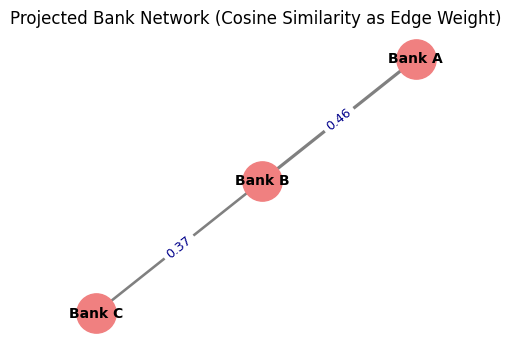

In [12]:
G_proj = nx.Graph()
for i in range(len(banks)):
    for j in range(i + 1, len(banks)):
        if similarity[i, j] > 0:
            G_proj.add_edge(banks[i], banks[j], weight=similarity[i, j])

# --- Visualize projection ---
plt.figure(figsize=(5, 4))
pos_proj = nx.spring_layout(G_proj, seed=42)

weights_proj = [G_proj[u][v]["weight"] * 5 for u, v in G_proj.edges()]
labels = { (u, v): f"{G_proj[u][v]['weight']:.2f}" for u, v in G_proj.edges() }

nx.draw_networkx_nodes(G_proj, pos_proj, node_color="lightcoral", node_size=800)
nx.draw_networkx_labels(G_proj, pos_proj, font_size=10, font_weight="bold")
nx.draw_networkx_edges(G_proj, pos_proj, width=weights_proj, edge_color="gray")
nx.draw_networkx_edge_labels(G_proj, pos_proj, edge_labels=labels, font_color="darkblue", font_size=9)

plt.title("Projected Bank Network (Cosine Similarity as Edge Weight)")
plt.axis("off")
plt.show()

In this projected network, the **cosine similarity** between two banks measures how similar their lending portfolios are — that is, how much they lend to the *same firms* and in what proportions.

$$
s_{ij} = \frac{\sum_k w_{ik} w_{jk}}{\sqrt{\sum_k w_{ik}^2} \sqrt{\sum_k w_{jk}^2}}
$$

- If $s_{ij} \approx 1$, Banks *i* and *j* lend to nearly the same set of firms → **high portfolio overlap**, **high common exposure**.  
- If $s_{ij} \approx 0$, their portfolios are unrelated → **low systemic linkage**.

Hence, in this setting we can use cosine similarity to capture potential for contagion. A shock to a firm affects all banks exposed to it, and banks with highly similar portfolios are more likely to experience simultaneou looses.


## **2. Paths, distances, and clustering**

Once we have a network built, we often want to understand **how easily nodes can reach one another**  
and **how tightly connected** their neighborhoods are.  
These structural measures tell us how information, value, or shocks can propagate through the system.


### 2.1. Paths

A **path** in a graph is a sequence of nodes connected by edges:

$$
P = (v_1, v_2, \dots, v_k)
$$

such that each consecutive pair $(v_i, v_{i+1})$ is an edge in the graph.

- The **length** of a path is the number of edges it contains.  
- A **shortest path** (or **geodesic**) between two nodes $i$ and $j$ is the path with the smallest length among all possible paths connecting them.

\
In financial terms:
- A path may represent a **chain of credit exposures**, **ownership links**, or **information channels** between entities.  
- The shorter the path, the **faster or stronger** the potential transmission of shocks or information.



### 2.2. Distance

The **distance** between two nodes $i$ and $j$, denoted $d(i, j)$,  
is the length of the shortest path between them.

If no path exists, the distance is considered **infinite** (nodes are disconnected).

Thus, we can define **Average path length (APL)** as:
 
$$
L = \frac{1}{n(n-1)} \sum_{i \neq j} d(i, j)
$$

which measures how “small” the world is within the network.

Smaller $L$ means higher **connectivity efficiency** — information or risk spreads faster.



### 2.3. Connectedness revisited

Now that we know more about distance, we can use distance-based measures to refine our understanding of connectedness:

- Nodes in the same component have finite distances.
- The **diameter** of a network is the largest shortest-path distance between any two nodes — it represents the “size” of the network in path terms.

$$
D = \max_{i,j} d(i,j)
$$



### 2.4. Clustering coefficient

While distance measures *global reachability*, the **clustering coefficient** captures *local cohesiveness* —  
how likely it is that two neighbors of a node are also connected.

For a node $i$ with degree $k_i$, let $E_i$ be the number of edges among its neighbors. Then the **local clustering coefficient** is:

$$
C_i = \frac{2E_i}{k_i (k_i - 1)}
$$

and the **average clustering coefficient** of the network is:

$$
C = \frac{1}{n} \sum_i C_i
$$

High clustering means nodes form **tight groups or communities**, while low clustering indicates a more **tree-like** or **sparse** structure.

The following table describes the important features of these concepts in a nutshell:

| Measure | Meaning |
|----------|-------------------------------|
| **Shortest path** | Minimum number of exposures or relationships linking two entities |
| **Distance** | Ease of contagion or information spread between entities |
| **Average path length** | System-wide efficiency of transmission |
| **Clustering coefficient** | Tendency of entities to form strongly interconnected groups (e.g., group of banks sharing similar exposures) |


\
Let's apply all these into our previous bank-firm network:

In [13]:
G_dist = nx.Graph()
for u, v, data in G_proj.edges(data=True):
    sim = data["weight"]
    # avoid division by zero
    dist = 1 / sim if sim > 0 else np.inf
    G_dist.add_edge(u, v, weight=dist)

# --- Shortest path lengths (weighted) ---
shortest_paths = dict(nx.all_pairs_dijkstra_path_length(G_dist, weight="weight"))

print("Shortest Path Distances Between Banks:\n")
for source, targets in shortest_paths.items():
    print(f"{source}: {targets}")

# --- Average path length ---
avg_path_length = nx.average_shortest_path_length(G_dist, weight="weight")
print(f"Average Path Length (weighted by inverse similarity): {avg_path_length:.3f}")

# --- Diameter (longest shortest path) ---
diameter = 0
for s in shortest_paths:
    for t in shortest_paths[s]:
        if shortest_paths[s][t] > diameter:
            diameter = shortest_paths[s][t]
print(f"Network Diameter (max shortest path): {diameter:.3f}")

# --- Clustering Coefficient ---
# For weighted networks, this measures triangle density weighted by edge strengths
clustering_coeffs = nx.clustering(G_proj, weight="weight")
avg_clustering = nx.average_clustering(G_proj, weight="weight")

print("Local Clustering Coefficients:")
for node, coeff in clustering_coeffs.items():
    print(f"{node}: {coeff:.3f}")

print(f"Average Clustering Coefficient: {avg_clustering:.3f}")


Shortest Path Distances Between Banks:

Bank A: {'Bank A': 0, 'Bank B': np.float64(2.173067468400883), 'Bank C': np.float64(4.860486717833733)}
Bank B: {'Bank B': 0, 'Bank A': np.float64(2.173067468400883), 'Bank C': np.float64(2.6874192494328497)}
Bank C: {'Bank C': 0, 'Bank B': np.float64(2.6874192494328497), 'Bank A': np.float64(4.860486717833733)}
Average Path Length (weighted by inverse similarity): 3.240
Network Diameter (max shortest path): 4.860
Local Clustering Coefficients:
Bank A: 0.000
Bank B: 0.000
Bank C: 0.000
Average Clustering Coefficient: 0.000


**Why is it that the clustering coefficient is always zero?**

In our very simple network of only 3 banks, there are no "triangles" between them. That is, looking at our projected network of bank-bank relationships, no bank has a "common neighbor" with another. 

## **3. Random Networks**

Real-world networks — from social systems to financial exposures — often display **structure**:  
some nodes are more connected than others, and patterns of clustering or hierarchy emerge.  
To understand whether such patterns are meaningful or generated simply by chance, we need a **baseline** model of what a network would look like if connections were formed *purely at random*.


### 3.1. The Erdős–Rényi (ER) Model

The simplest model of a random network is the **Erdős–Rényi (ER)** graph, denoted:

$$
G(n, p)
$$

where:
- $n$: number of nodes  
- $p$: probability that *any two* nodes are connected by an edge, independently of others

Alternatively, the model can also be defined as $G(n, m)$, where:
- $n$: number of nodes  
- $m$: total number of edges, chosen uniformly at random among all possible pairs.

In both versions, connections are **stochastic**, without preference or structure.



### 3.2. Expected Number of Links and Average Degree

In $G(n, p)$, each of the $\frac{n(n-1)}{2}$ possible edges exists with probability $p$.

Thus, the **expected number of edges** is:

$$
\mathbb{E}[|E|] = p \frac{n(n-1)}{2}
$$

and the **expected degree** of each node is:

$$
\langle k \rangle = p (n - 1)
$$

This tells us that increasing $p$ or $n$ makes the network denser.



### 3.3. Degree Distribution

In an ER network, the degree $k_i$ of a node (number of edges connected to it)  
follows a **binomial distribution**:

$$
P(k) = \binom{n-1}{k} p^k (1-p)^{n-1-k}
$$

For large $n$ and small $p$, this converges to a **Poisson distribution**:

$$
P(k) \approx \frac{e^{-\langle k \rangle} \langle k \rangle^k}{k!}
$$

This implies that:
- Most nodes have degrees close to the average $\langle k \rangle$,  
- High-degree nodes (hubs) are *exponentially rare*.

In contrast, **real networks** often show *heavy-tailed* degree distributions —  
a few nodes have very high connectivity — which random networks cannot reproduce. That is, **real networks are not Poisson**. We will explore this further in the upcoming lessons.



### 3.4. Connectedness and Phase Transition

As $p$ increases, the network transitions from many small components to a single large one:

- For $p < \frac{1}{n}$, most nodes are isolated.  
- At $p \approx \frac{1}{n}$, a **giant connected component** emerges.  
- For $p > \frac{\ln n}{n} $, the network becomes almost surely **fully connected**.

This threshold behavior is a hallmark of random graph theory —  
a small increase in $p$  can suddenly make the system globally connected.


### 3.5. Clustering Coefficient in Random Networks

In ER networks, the **clustering coefficient** is equal to the connection probability $p$:

$$
C = p
$$

because each pair of a node’s neighbors is connected independently with probability $p$.

Therefore, random networks typically exhibit **low clustering**,  
unlike real-world systems where nodes often form tightly connected groups.



\
So, after all this, **why are random networks useful in finance?**


A random network represents a **benchmark** — a system where links (e.g., loans, exposures, ownership ties) are formed *without preference or structure*. Thus, any we can extract patterns that may be useful from any deviations from the random benchmark. 

- **Random interbank network:** banks lend randomly to others, regardless of size or risk.  
- **Random correlation network:** asset co-movements occur by chance, not economic linkage.

By comparing real financial networks to an ER baseline, we can measure **how structured**, **clustered**, or **systemically vulnerable** they truly are!



## **4. An example of Random Network**

To illustrate all these concepts, let's work on creating a random network (ER style) of investors and investments in mutual funds.

In [22]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter


n_investors = 15
n_funds     = 12
p_link      = 0.18   # probability an investor holds a fund (ER-style bipartite)
rng_seed    = 42
np.random.seed(rng_seed)

investors = [f"Inv_{i}" for i in range(n_investors)]
funds     = [f"Fund_{j}" for j in range(n_funds)]

# Build random bipartite graph (ER bipartite)
B = nx.Graph()
B.add_nodes_from(investors, bipartite=0)
B.add_nodes_from(funds, bipartite=1)

for inv in investors:
    for fund in funds:
        if np.random.rand() < p_link:
            w = np.random.randint(1, 6) # random weights in links between 1 and 5 (millions)
            B.add_edge(inv, fund, weight=w)


m_edges = B.number_of_edges()
print(f"Bipartite edges (investor–fund links): {m_edges}")

Bipartite edges (investor–fund links): 33


In [23]:
# Biadjacency matrix Investors × Funds (weights)
biadj = bipartite.biadjacency_matrix(B, row_order=investors, column_order=funds, weight="weight").toarray()
biadj_df = pd.DataFrame(biadj, index=investors, columns=funds)
display(biadj_df)

,Fund_0,Fund_1,Fund_2,Fund_3,Fund_4,Fund_5,Fund_6,Fund_7,Fund_8,Fund_9,Fund_10,Fund_11
Inv_0,0,0,0,0,3,3,0,0,0,2,0,0
Inv_1,4,0,0,0,0,0,0,4,0,0,3,0
Inv_2,0,0,0,0,0,1,0,0,0,4,0,0
Inv_3,0,0,1,0,0,0,0,0,0,0,0,0
Inv_4,0,0,0,4,5,0,0,0,0,0,0,5
Inv_5,1,0,0,3,0,0,0,0,0,0,0,0
Inv_6,0,5,0,0,0,0,3,0,0,0,0,0
Inv_7,0,5,0,0,0,0,0,5,0,0,0,0
Inv_8,0,0,0,0,4,0,0,0,0,0,0,0
Inv_9,1,0,5,0,3,0,0,4,0,1,0,2


Now we can project this network to an investor-investors network to analyze the links between investors given their investments into different funds. We will first look simply at the number of "co-holdings" to get a raw estimate. Then, we can implement the classic cosine similarity projection:

In [24]:
# Co-holdings projection:
cohold = biadj @ biadj.T
np.fill_diagonal(cohold, 0)
A_count = pd.DataFrame(cohold, index=investors, columns=investors)

G_proj_count = nx.Graph()
for i, u in enumerate(investors):
    for j, v in enumerate(investors):
        if j <= i:
            continue
        if A_count.iloc[i, j] > 0:
            G_proj_count.add_edge(u, v, weight=A_count.iloc[i, j])

# Cosine similarity projection 
cos = cosine_similarity(biadj)  
np.fill_diagonal(cos, 0.0)
A_cos = pd.DataFrame(cos, index=investors, columns=investors)

G_proj_cos = nx.Graph()
for i, u in enumerate(investors):
    for j, v in enumerate(investors):
        if j <= i:
            continue
        if A_cos.iloc[i, j] > 0:
            G_proj_cos.add_edge(u, v, weight=A_cos.iloc[i, j])

print(f"\nInvestor–Investor edges (co-holdings ≥1): {G_proj_count.number_of_edges()}")
print(f"Investor–Investor edges (cosine > 0):     {G_proj_cos.number_of_edges()}")



Investor–Investor edges (co-holdings ≥1): 30
Investor–Investor edges (cosine > 0):     30


For ease of visualization, we can also plot projected network, for instance the cosine-based one:

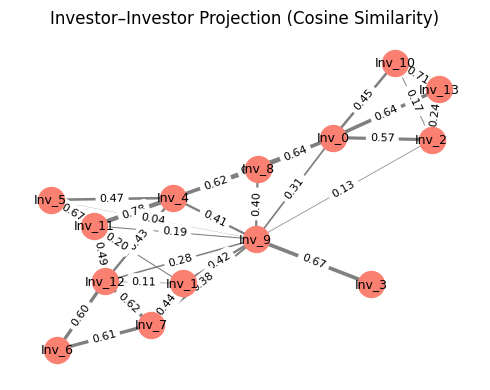

In [34]:
plt.figure(figsize=(5,4))
pos = nx.spring_layout(G_proj_cos, seed=rng_seed)
nx.draw_networkx_nodes(G_proj_cos, pos, node_color="salmon", node_size=350)
nx.draw_networkx_labels(G_proj_cos, pos, font_size=9)
w = [G_proj_cos[u][v]["weight"]*4 for u,v in G_proj_cos.edges()]
nx.draw_networkx_edges(G_proj_cos, pos, width=w, edge_color="gray")
nx.draw_networkx_edge_labels(
    G_proj_cos, pos,
    edge_labels={(u,v): f"{G_proj_cos[u][v]['weight']:.2f}" for u,v in G_proj_cos.edges()},
    font_size=8
)
plt.title("Investor–Investor Projection (Cosine Similarity)")
plt.axis("off")
plt.tight_layout()
plt.show()

Finally, we can analyze connectedness metrics based on these projections:

In [35]:
# Connectedness metrics on projection (use cosine-distance)

def metrics_on_graph(G, weighted=False):
    if G.number_of_nodes() == 0 or nx.number_connected_components(G) > 1:
        if G.number_of_nodes() == 0:
            return {"avg_deg": 0, "density": 0, "avg_path": np.nan, "diameter": np.nan, "avg_clust": 0}
        comp = max(nx.connected_components(G), key=len)
        H = G.subgraph(comp).copy()
    else:
        H = G

    avg_deg = sum(dict(H.degree()).values()) / H.number_of_nodes()
    density = nx.density(H)

    if weighted:
        Hdist = nx.Graph()
        for u, v, d in H.edges(data=True):
            sim = d.get("weight", 1.0)
            dist = 1.0 / sim if sim > 0 else np.inf
            Hdist.add_edge(u, v, weight=dist)
        avg_path = nx.average_shortest_path_length(Hdist, weight="weight") if Hdist.number_of_edges() else np.nan
        avg_clust = nx.average_clustering(H, weight="weight")
        sp = dict(nx.all_pairs_dijkstra_path_length(Hdist, weight="weight"))
        diam = max(max(d.values()) for d in sp.values()) if Hdist.number_of_edges() else np.nan
    else:
        avg_path = nx.average_shortest_path_length(H) if H.number_of_edges() else np.nan
        avg_clust = nx.average_clustering(H)
        sp = dict(nx.all_pairs_shortest_path_length(H))
        diam = max(max(d.values()) for d in sp.values()) if H.number_of_edges() else np.nan

    return {
        "n_nodes_cc": H.number_of_nodes(),
        "n_edges_cc": H.number_of_edges(),
        "avg_deg": avg_deg,
        "density": density,
        "avg_path": avg_path,
        "diameter": diam,
        "avg_clust": avg_clust,
    }

m_count = metrics_on_graph(G_proj_count, weighted=False)
m_cos   = metrics_on_graph(G_proj_cos,   weighted=True)

print("Co-holdings (unweighted):", m_count)
print("Cosine similarity (weighted):", m_cos)

Co-holdings (unweighted): {'n_nodes_cc': 14, 'n_edges_cc': 30, 'avg_deg': 4.285714285714286, 'density': 0.32967032967032966, 'avg_path': 1.901098901098901, 'diameter': 4, 'avg_clust': 0.6611111111111112}
Cosine similarity (weighted): {'n_nodes_cc': 14, 'n_edges_cc': 30, 'avg_deg': 4.285714285714286, 'density': 0.32967032967032966, 'avg_path': np.float64(4.459277234097334), 'diameter': np.float64(8.75969017836465), 'avg_clust': 0.35541101211798426}


As you can see, both projections (count- and cosine-based) deliver similar (but not quite identical) metrics. So, sometimes we would like to opt for one or another form of projection. Most of the time, however, we would opt for the cosine metric if the strength of the links is an important factor.

\
Let's now compare this network with a random one in the spirit of ER, generated so as to match the same $p$ we have in our network:

In [28]:
if m_count["n_nodes_cc"] > 1:
    target_n = m_count["n_nodes_cc"]
    target_density = m_count["density"]
    
    p_star = target_density
    ER = nx.gnp_random_graph(target_n, p_star, seed=rng_seed)
    m_er = metrics_on_graph(ER, weighted=False)
    print("\n=== ER baseline on investors (same n, similar density) ===")
    print(f"n={target_n}, p*≈{p_star:.3f}")
    print("ER metrics:", m_er)


=== ER baseline on investors (same n, similar density) ===
n=14, p*≈0.330
ER metrics: {'n_nodes_cc': 14, 'n_edges_cc': 37, 'avg_deg': 5.285714285714286, 'density': 0.4065934065934066, 'avg_path': 1.6263736263736264, 'diameter': 3, 'avg_clust': 0.4480725623582767}


This metrics already tell us something, but we can compare them more clearly using **degree distribution**:

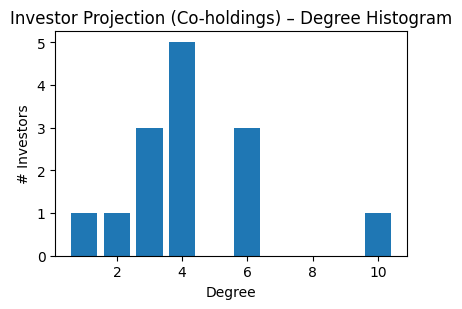

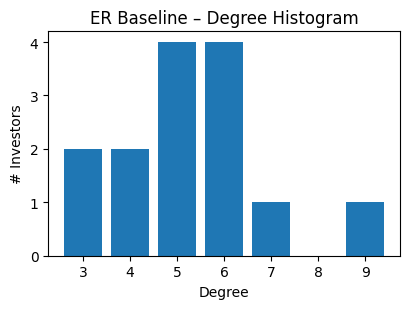

In [36]:
def degree_histogram(G, title):
    degs = [d for _, d in G.degree()]
    if len(degs) == 0:
        print(f"{title}: empty graph.")
        return
    cnt = Counter(degs)
    xs, ys = zip(*sorted(cnt.items()))
    plt.figure(figsize=(4.2,3.2))
    plt.bar(xs, ys)
    plt.xlabel("Degree")
    plt.ylabel("# Investors")
    plt.title(title)
    plt.tight_layout()
    plt.show()

degree_histogram(G_proj_count, "Investor Projection (Co-holdings) – Degree Histogram")
if 'ER' in locals():
    degree_histogram(ER, "ER Baseline – Degree Histogram")


If we plot these 2 together for better visualization:

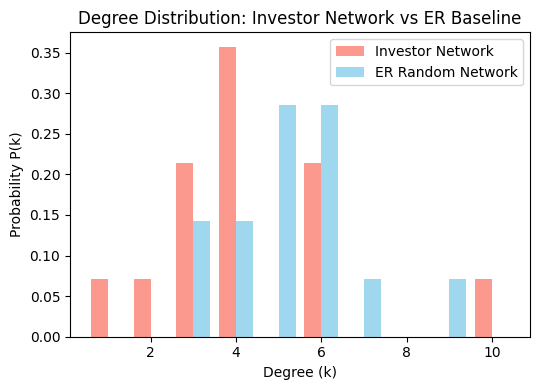

In [39]:

if "G_proj_count" not in locals() or "ER" not in locals():
    print("Please make sure you have run the investor projection and ER graph code first.")
else:
    
    deg_proj = [d for _, d in G_proj_count.degree()]
    deg_er   = [d for _, d in ER.degree()]

    
    count_proj = Counter(deg_proj)
    count_er   = Counter(deg_er)

    
    all_degrees = sorted(set(count_proj.keys()) | set(count_er.keys()))
    proj_freqs = [count_proj.get(k, 0) for k in all_degrees]
    er_freqs   = [count_er.get(k, 0) for k in all_degrees]

    proj_probs = np.array(proj_freqs) / sum(proj_freqs)
    er_probs   = np.array(er_freqs) / sum(er_freqs)

    plt.figure(figsize=(5.5,4))
    plt.bar(np.array(all_degrees)-0.2, proj_probs, width=0.4, label="Investor Network", color="salmon", alpha=0.8)
    plt.bar(np.array(all_degrees)+0.2, er_probs,   width=0.4, label="ER Random Network", color="skyblue", alpha=0.8)
    plt.xlabel("Degree (k)")
    plt.ylabel("Probability P(k)")
    plt.title("Degree Distribution: Investor Network vs ER Baseline")
    plt.legend()
    plt.tight_layout()
    plt.show()


**How should I interpret these results?**
  
The plot above compares the **degree distribution** of the real (projected) *Investor–Investor* network  
with that of a **random (Erdős–Rényi)** network of similar size and density.

- In the **ER network**, degrees follow a narrow, roughly **Poisson-like** distribution —  
  most investors have about the same number of connections.
  
- In the **empirical investor network**, we may observe a **broader** or **skewed** distribution —  
  a few investors are connected to many others (high degree), while most have few links.

In short, deviations from the ER benchmark reveal **non-random structure** in the financial system —  
a sign of correlated investment behavior or common exposures that can amplify contagion risk.


## **5. Conclusion**

Well done! In this lesson we have gone over Random networks, an important concept in network theory. Main message, however, is that **real networks are not random**. Yet, random networks such ER model are extremely helpful because they allow us to identify patterns in a real network.

In the next lesson, we will make more progress to understand why real networks deviate from the randomness in ER. 

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
